# Entropy, Gini impuirity and infromatiom Gain:

In [4]:
# import librearies basic and using in dataset:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
# model libraries:
from sklearn.linear_model import LinearRegression
# import libraries for entropy and gini:

import math

In [6]:
# Example dataset 
# Let's say you have a dataset with two classes ,A and B,:
# suppose in a dataset od=f 4 element in class A and 6 element in class B:

n_A = 4
n_B = 6
Total = n_A + n_B
# calculate entropy:
entropy = - (n_A / (n_A + n_B)) * math.log2(n_A / (n_A + n_B)) - (n_B / (n_A + n_B)) * math.log2(n_B / (n_A + n_B))
entropy

0.9709505944546686

In [7]:
# let's calculate the proportions:

proportion_A = n_A / Total
proportion_B = n_B / Total
print("proportion_A:", proportion_A)
print("proportion_B:", proportion_B)

proportion_A: 0.4
proportion_B: 0.6


In [8]:
# entropy calculated:
entropy = - (proportion_A) * math.log2(proportion_A) - (proportion_B) * math.log2(proportion_B)
entropy

0.9709505944546686

In [9]:
# Gini impurity:
gini = 1 - (proportion_A ** 2 + proportion_B ** 2)
gini

0.48

In [15]:
# Information gain:
# Assumeing a split on some feature divided the dataset into two subsets
# subset 1:  2 element in class A and 3 element in class B:
# subset 2: 2 element in class A and 3 element in class B:

n_A_1 = 2
n_B_1 = 3
n_A_2 = 2
n_B_2 = 3

# calculate the proportions:

proportion_A_1 = n_A_1 / (n_A_1 + n_B_1)
proportion_B_1 = n_B_1 / (n_A_1 + n_B_1)

proportion_A_2 = n_A_2 / (n_A_2 + n_B_2)
proportion_B_2 = n_B_2 / (n_A_2 + n_B_2)
# print the proportions:
print("proportion_A_1:", proportion_A_1)
print("proportion_B_1:", proportion_B_1)
print("proportion_A_2:", proportion_A_2)
print("proportion_B_2:", proportion_B_2)

#  entropy and size of subset:

entropy_1 = - (n_A_1 / (n_A_1 + n_B_1)) * math.log2(n_A_1 / (n_A_1 + n_B_1)) - (n_B_1 / (n_A_1 + n_B_1)) * math.log2(n_B_1 / (n_A_1 + n_B_1))
entropy_2 = - (n_A_2 / (n_A_2 + n_B_2)) * math.log2(n_A_2 / (n_A_2 + n_B_2)) - (n_B_2 / (n_A_2 + n_B_2)) * math.log2(n_B_2 / (n_A_2 + n_B_2))

print("entropy_1:", entropy_1)
print("entropy_2:", entropy_2)

# calculate the information gain:

information_gain = entropy - (proportion_A_1 * entropy_1 + proportion_A_2 * entropy_2)
print("information_gain:", information_gain)

proportion_A_1: 0.4
proportion_B_1: 0.6
proportion_A_2: 0.4
proportion_B_2: 0.6
entropy_1: 0.9709505944546686
entropy_2: 0.9709505944546686
information_gain: 0.19419011889093363


---

# Decision Tree Classifier in python:

In [16]:
# import libraries for Decision Tree:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [43]:
# load the titanic dataset:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [44]:
# drop the deck columns:
df = df.drop('deck', axis=1)
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [45]:
# impute the missing values in age and fare:
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
# impute the missing values in embarked and embark_town:
df['embarked'].fillna('S', inplace=True)
df['embark_town'].fillna('Southampton', inplace=True)
df.head() 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13888\1708419463.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13888\1708419463.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [46]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [48]:
# Encode the categorical variables and objects variables use for loop and label encoding:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']):
    df[col] = le.fit_transform(df[col])
    

In [49]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [50]:
# split the data X and y:
X = df.drop('survived', axis=1)
y = df['survived']

In [60]:
#it data train and test split:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
# import the linear regression model:
from sklearn.linear_model import LinearRegression
# create the model:
model = LinearRegression()
# fit the model:
model.fit(X_train, y_train)
# predict the model:
y_pred = model.predict(X_test)

In [62]:
# creat and train the model and predict the model:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
# predict the model:
y_pred = model.predict(X_test)

In [63]:
# evaluate the model:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[105   0]
 [  0  74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



In [64]:
# save the decision tree classifier:
from sklearn.tree import export_graphviz
export_graphviz(model, out_file='tree.dot', feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True, rounded=True)

---

# Rondom Forset:

In [66]:
# import the libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.tree import export_graphviz

In [67]:
# load the tips dataset:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# Encode the categorical variables and objects variables use for loop and label encoding:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include=['object', 'category']):
    df[col] = le.fit_transform(df[col]) 

In [ ]:
df.head() 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


In [73]:
# split the data X and y:
X = df.drop('sex', axis=1)
y = df['sex']


In [ ]:
# train test split the data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [75]:
# create train the model and predict the model:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
# predict the model:
y_pred = model.predict(X_test)

In [76]:
# evaluate the model:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6122448979591837
Confusion Matrix:
 [[ 9 10]
 [ 9 21]]
              precision    recall  f1-score   support

           0       0.50      0.47      0.49        19
           1       0.68      0.70      0.69        30

    accuracy                           0.61        49
   macro avg       0.59      0.59      0.59        49
weighted avg       0.61      0.61      0.61        49



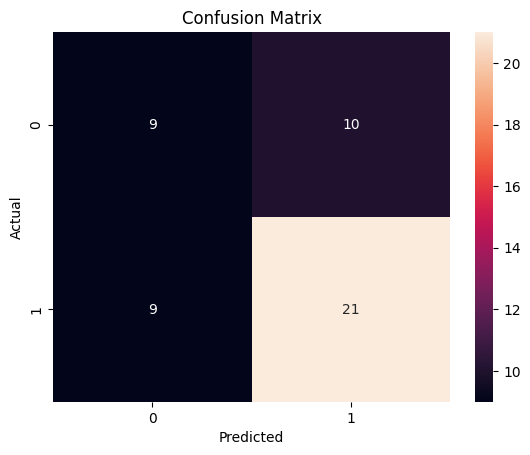

In [ ]:
# Draw the confusion matrix using heatmap:
from sklearn import metrics
from sklearn.metrics import confusion_matrix
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [86]:
# use the random forest Regressor task:
X = df.drop('tip', axis=1)
y = df['tip']

# train test split the data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create train the model and predict the model:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
# predict the model:
y_pred = model.predict(X_test)

# evaluate the model:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#  Regression metrics in evaluate the model:
print('mean squared error:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))
print('Mean absolute error:', mean_absolute_error(y_test, y_pred))
print('root mean squared error:', np.sqrt(mean_squared_error(y_test, y_pred)))

mean squared error: 0.903669720612246
R2 score: 0.2770476507083268
Mean absolute error: 0.7478387755102043
root mean squared error: 0.9506154430747725
